<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


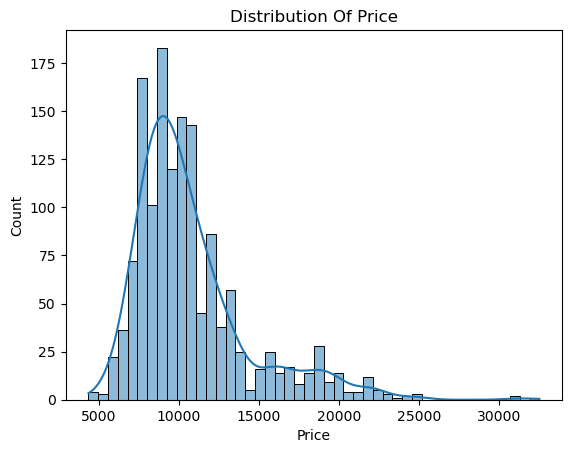

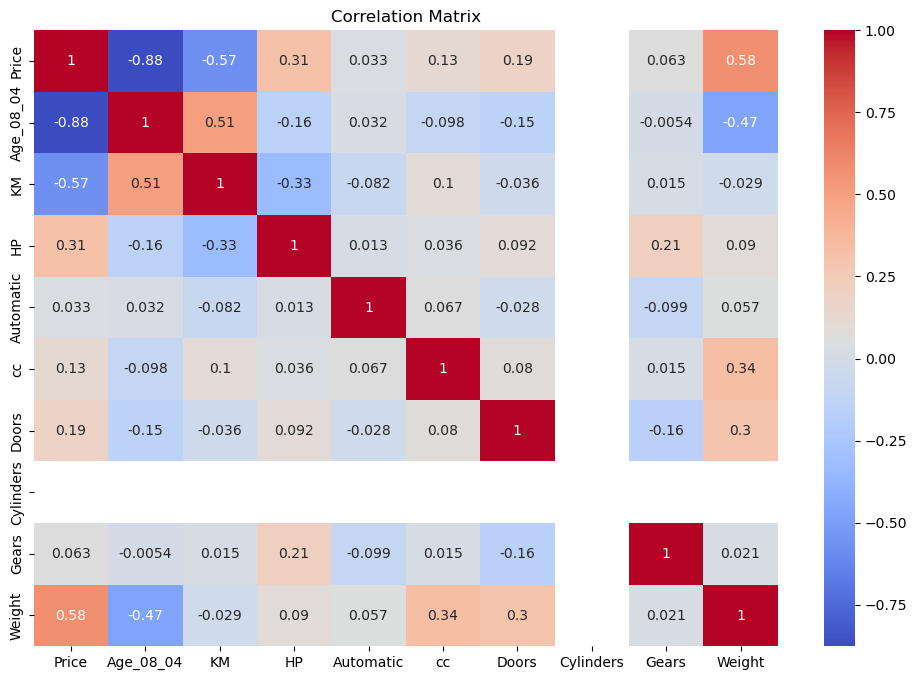


----MODEL RESULTS 1----
R2 Score : 0.8348888040611081
RMSE : 1484.265415329652

----MODEL 2 RESULTS----
R2 Score : 0.836018013473348
RMSE : 1479.1811993112494

----MODEL 3 RESULTS----
R2 Score : 0.823187471528688
RMSE : 1535.959710511224

----RIDGE MODEL RESULTS----
R2 Score : 0.8350658145414693
RMSE : 1483.4695850205765

----LASSO MODEL RESULTS----
R2 Score : 0.8349004102719381
RMSE : 1484.2132474558114


,Feature,Coefficient
8,Weight,1362.138679
10,Fuel_Type_Petrol,445.102711
2,HP,210.253304
7,Gears,103.946283
3,Automatic,34.136075
6,Cylinders,0.000000
4,cc,-12.885069
9,Fuel_Type_Diesel,-21.270885
5,Doors,-57.436845
1,KM,-608.570564


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\ToyotaCorolla - MLR.csv")

# ==========================================
# DATA OVERVIEW
# ==========================================

print("\n-----INFO-----")
print(df.info())

print("\n-----DESCRIPTION-----")
print(df.describe())

print("\n-----NULL VALUES-----")
print(df.isnull().sum())

# ==========================================
# EDA
# ==========================================

plt.figure()
sns.histplot(df["Price"], kde=True)
plt.title("Distribution Of Price")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==========================================
# PREPROCESSING
# ==========================================

from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

X = df.drop("Price", axis=1)
y = df["Price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Save Model 1 train-test data
X_train1 = X_train
X_test1 = X_test
y_train1 = y_train
y_test1 = y_test

# ==========================================
# IMPORT MODELS & METRICS
# ==========================================

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ==========================================
# MODEL 1
# ==========================================

lr1 = LinearRegression()

lr1.fit(X_train1, y_train1)

y_pred1 = lr1.predict(X_test1)

print("\n----MODEL 1 RESULTS----")
print("R2 Score :", r2_score(y_test1, y_pred1))
print("RMSE :", np.sqrt(mean_squared_error(y_test1, y_pred1)))

# ==========================================
# MODEL 2
# Removing Doors and cc
# ==========================================

X2 = df.drop(["Price", "Doors", "cc"], axis=1)

X2 = StandardScaler().fit_transform(X2)

X2_train, X2_test, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

lr2 = LinearRegression()

lr2.fit(X2_train, y_train2)

y_pred2 = lr2.predict(X2_test)

print("\n----MODEL 2 RESULTS----")
print("R2 Score :", r2_score(y_test2, y_pred2))
print("RMSE :", np.sqrt(mean_squared_error(y_test2, y_pred2)))

# ==========================================
# MODEL 3
# Removing Weakest Feature Separately
# ==========================================

X3 = df.drop(["Price", "Doors", "cc", "HP"], axis=1)

X3 = StandardScaler().fit_transform(X3)

X3_train, X3_test, y_train3, y_test3 = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42
)

lr3 = LinearRegression()

lr3.fit(X3_train, y_train3)

y_pred3 = lr3.predict(X3_test)

print("\n----MODEL 3 RESULTS----")
print("R2 Score :", r2_score(y_test3, y_pred3))
print("RMSE :", np.sqrt(mean_squared_error(y_test3, y_pred3)))

# ==========================================
# RIDGE REGRESSION
# ==========================================

ridge = Ridge(alpha=1)

ridge.fit(X_train1, y_train1)

y_pred_ridge = ridge.predict(X_test1)

print("\n----RIDGE MODEL RESULTS----")
print("R2 Score :", r2_score(y_test1, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test1, y_pred_ridge)))

# ==========================================
# LASSO REGRESSION
# ==========================================

lasso = Lasso(alpha=0.05)

lasso.fit(X_train1, y_train1)

y_pred_lasso = lasso.predict(X_test1)

print("\n----LASSO MODEL RESULTS----")
print("R2 Score :", r2_score(y_test1, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test1, y_pred_lasso)))

# ==========================================
# COEFFICIENT INTERPRETATION
# ==========================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr1.coef_
})

print("\n-----COEFFICIENTS-----")
print(coef_df.sort_values(by="Coefficient", ascending=False))